In [48]:
%%capture
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random
import json
from pathlib import Path
from collections import defaultdict
import re
import os
from tqdm import tqdm
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split

In [50]:
# converting the data into csv 

IMG_DIR   = Path("/kaggle/input/mini-coco2014-dataset-for-image-captioning/Images")
JSON_PATH = Path("/kaggle/input/mini-coco2014-dataset-for-image-captioning/captions.json")
OUT_CSV   = Path("/kaggle/working/captions.csv")


with open(JSON_PATH, "r") as f:
    captions_data = json.load(f)


group = defaultdict(list)

for i in captions_data:
    group[i["image_id"]].append(i["caption"])


rows = []
for img_id, caps in group.items():
    img_file = f"COCO_train2014_{img_id:012d}.jpg"
    img_path = str(IMG_DIR / img_file)
    for cap in caps:
        rows.append([img_path, cap])


df = pd.DataFrame(rows, columns=["image_path", "caption"])
df.to_csv(OUT_CSV, index=False)

print(f"✅ Saved {len(df)} rows to {OUT_CSV}")


✅ Saved 93950 rows to /kaggle/working/captions.csv


In [51]:
df.head()

,image_path,caption
0,/kaggle/input/mini-coco2014-dataset-for-image-...,A white square kitchen with tile floor that ne...
1,/kaggle/input/mini-coco2014-dataset-for-image-...,A white kitchen in a home with the light on.
2,/kaggle/input/mini-coco2014-dataset-for-image-...,A kitchen with a tile floor has cabinets with ...
3,/kaggle/input/mini-coco2014-dataset-for-image-...,A white kitchen without doors on the cabinets.
4,/kaggle/input/mini-coco2014-dataset-for-image-...,"A white kitchen filled with pots, pans and dis..."


In [52]:
df['image_path'][0]

'/kaggle/input/mini-coco2014-dataset-for-image-captioning/Images/COCO_train2014_000000299675.jpg'

In [53]:
# to drop duplicates both image and caprion is same 


caps_per_image = df.groupby("image_path").size()

print("Min captions per image:", caps_per_image.min())

print("Max captions per image:", caps_per_image.max())


before = len(df)

df = df.drop_duplicates(subset=["image_path", "caption"])

after = len(df)

print(f"✅ Removed {before - after} exact duplicates")


Min captions per image: 5
Max captions per image: 6
✅ Removed 27 exact duplicates


In [54]:
df.shape

(93923, 2)

In [55]:
#path of each image exists 

missing = df[~df["image_path"].apply(lambda x: Path(x).exists())]

print("Missing images:", len(missing))


Missing images: 0


In [56]:
# checking captions length 

df["cap_len"] = df["caption"].apply(lambda x: len(x.split()))

print(df["cap_len"].describe())


count    93923.000000
mean        10.459217
std          2.385413
min          6.000000
25%          9.000000
50%         10.000000
75%         11.000000
max         49.000000
Name: cap_len, dtype: float64


In [57]:
# removing outlier captions 

CSV_PATH = "/kaggle/working/captions.csv"
df = pd.read_csv(CSV_PATH)


def count_words(s):
    return len(str(s).split())


df["cap_len"] = df["caption"].apply(count_words)


MAX_LEN = 20
df = df[df["cap_len"] <= MAX_LEN].reset_index(drop=True)

print(f" Remaining captions: {len(df)}")
print(df["cap_len"].describe())


df.drop(columns=["cap_len"], inplace=True)
df.to_csv("/kaggle/working/captions_clean.csv", index=False)

# we save the final max 20 words captions to captions_clean

 Remaining captions: 93401
count    93401.000000
mean        10.374332
std          2.085812
min          6.000000
25%          9.000000
50%         10.000000
75%         11.000000
max         20.000000
Name: cap_len, dtype: float64


In [58]:
df.shape

(93401, 2)

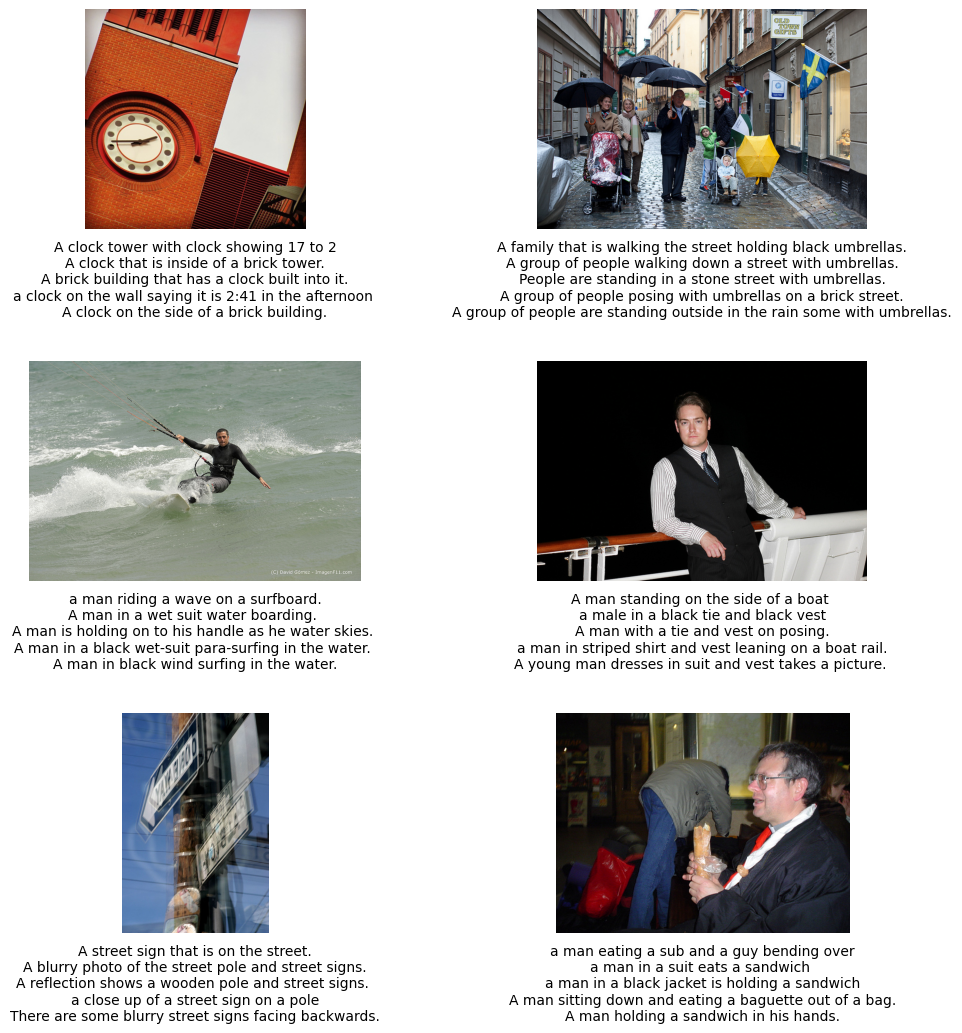

In [59]:

img_paths = random.sample(list(df["image_path"].unique()), 6)

plt.figure(figsize=(12, 12))

for i, img_path in enumerate(img_paths, 1):
    ax = plt.subplot(3, 2, i)          # 3 rows, 2 columns
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    
    # Get captions
    caps = df[df["image_path"] == img_path]["caption"].tolist()
    
    # Place captions below the image without numbering
    ax.text(
        0.5, -0.05, "\n".join(caps),
        ha='center', va='top', fontsize=10, wrap=True, transform=ax.transAxes
    )

plt.subplots_adjust(hspace=0.6)  
plt.show()

In [60]:
# lets tokenize and map the words to integers .. 


captions = df["caption"].tolist()

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9 ]", "", text)  # keep letters/numbers only
    return text.split()


word_counts = {}

for caption in captions:
    for word in tokenize(caption):
        word_counts[word] = word_counts.get(word, 0) + 1


min_freq = 5
words = [w for w,f in word_counts.items() if f >= min_freq]


special_tokens = ["<pad>", "<start>", "<end>", "<unk>"]


vocab_words = special_tokens + words


word_to_index = {w:i for i,w in enumerate(vocab_words)}   # string -> index
index_to_word = {i:w for i,w in enumerate(vocab_words)}   # index -> string

print("Vocabulary size:", len(vocab_words))


Vocabulary size: 4505


In [61]:
# MAX_LEN = 20 

def encode_caption(caption, max_len=MAX_LEN):

    words = tokenize(caption)[:max_len-2]         # trim to fit max_len
    
    tokens = [word_to_index["<start>"]]           # start token
    
    tokens = tokens + [word_to_index.get(w, word_to_index["<unk>"]) for w in words]  # words
    
    tokens.append(word_to_index["<end>"])         # end token

    
    # Pad if needed
    while len(tokens) < max_len:
        tokens.append(word_to_index["<pad>"])
    
    return tokens


# example 
print("Original caption:", captions[0])
print("")
print("Encoded:", encode_caption(captions[0]))



Original caption: A white square kitchen with tile floor that needs repairs 

Encoded: [1, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 2, 0, 0, 0, 0, 0, 0, 0, 0]


In [62]:
# to encode each caption in my df 

encoded_captions = [encode_caption(cap) for cap in df['caption'].tolist()]

captions_np = np.array(encoded_captions)

--------------------------------------------------------------------------------------------------------------------------------------------------

# **EFFICIENT NET B3 ENCODER** :

In [63]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Reshape, Lambda , Add
from tensorflow.keras.preprocessing.sequence import pad_sequences



# Parameters

img_size = 300
spatial_size = 10
embed_size = 256

# Backbone

base_model = EfficientNetB3(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3))
base_model.trainable = False

# Encoder

inputs = Input(shape=(img_size, img_size, 3))

# EfficientNet features

x = base_model(inputs)   # [B, H_feat, W_feat, 1536]

x = Lambda(lambda t: tf.image.resize(t, (spatial_size, spatial_size)))(x)  # [B, 10, 10, 1536]

x = Reshape((spatial_size*spatial_size, 1536))(x)           # [B, 100, 1536]

outputs = Dense(embed_size)(x)                               # [B, 100, embed_size]

image_encoder = Model(inputs, outputs)

image_encoder.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 10, 10, 1536)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_2 (Reshape)             │ (None, 100, 1536)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100, 256)       │       393,472 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,177,007 (42.64 MB)

 Trainable params: 393,472 (1.50 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [64]:
# Image loading + preprocessing helper

def load_and_preprocess(img_path):
    img = Image.open(img_path).convert("RGB").resize((img_size, img_size))
    img = np.array(img)
    img = preprocess_input(img)        # <-- Correct EfficientNet preprocessing to [-1, 1]
    return img

# **EXTRACTING IMAGE FATURES**

import os
import numpy as np
from tqdm import tqdm
from PIL import Image

# Parameters

chunk_size = 2000

save_dir = "/kaggle/working/features"

os.makedirs(save_dir, exist_ok=True)


# Assuming df['image_path'] contains all image paths

unique_images = df['image_path'].drop_duplicates().tolist()

n_images = len(unique_images)

print(f"Total unique images: {n_images}")

n_chunks = (n_images + chunk_size - 1) // chunk_size

print(f"Number of chunks: {n_chunks}")


# ----------------------
# Extract features chunk by chunk
# ----------------------
for chunk_idx in range(n_chunks):
    
    start = chunk_idx * chunk_size
    
    end = min(start + chunk_size, n_images)
    
    batch_paths = unique_images[start:end]
    
    imgs = np.array([load_and_preprocess(p) for p in batch_paths])
    
    # Pass through encoder
    features = image_encoder.predict(imgs, batch_size=32, verbose=1)
    
    # Save chunk
    np.save(os.path.join(save_dir, f"image_features_chunk_{chunk_idx}.npy"), features)
    print(f"✅ Saved chunk {chunk_idx}, images {start}-{end-1}, shape {features.shape}")


save_dir = "/kaggle/working/features"

os.makedirs(save_dir, exist_ok=True)

# Merge all chunks

all_features = []

for f in sorted(os.listdir(save_dir)):
    if f.startswith("image_features_chunk"):
        chunk = np.load(os.path.join(save_dir, f))
        all_features.append(chunk)


all_features = np.vstack(all_features)

print(f" All features merged: {all_features.shape}")

np.save(os.path.join(save_dir, "image_features_new.npy"), all_features)

------------------------------------------------------------------------------------------------------------------------------------------------

# **LOADING AND SPLITTING OUR DATA**

In [65]:

# Load what you already have

all_features = np.load("/kaggle/input/features/image_features_new.npy")  # shape [n_images, 100, 256]

unique_images = df['image_path'].drop_duplicates().tolist()

img_to_idx = {path: idx for idx, path in enumerate(unique_images)}


# Captions already encoded
captions_np = np.array(encoded_captions)   # shape [n_captions, max_len]


# Inputs and targets
X_caps = captions_np[:, :-1]

Y_caps = captions_np[:, 1:]

Y_caps = np.expand_dims(Y_caps, -1)   # [B, T, 1]



In [66]:

# 1. Unique images split

unique_images = df['image_path'].unique()

train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)

val_imgs, test_imgs   = train_test_split(temp_imgs, test_size=0.5, random_state=42)

# 2. Build split dataframes

train_df = df[df['image_path'].isin(train_imgs)]

val_df   = df[df['image_path'].isin(val_imgs)]

test_df  = df[df['image_path'].isin(test_imgs)]


# 3. Extract captions & targets

cap_train  = X_caps[train_df.index]
y_train    = Y_caps[train_df.index]
paths_train = train_df['image_path'].tolist()

cap_val    = X_caps[val_df.index]
y_val      = Y_caps[val_df.index]
paths_val   = val_df['image_path'].tolist()

cap_test   = X_caps[test_df.index]
y_test     = Y_caps[test_df.index]
paths_test  = test_df['image_path'].tolist()


print("Train captions:", cap_train.shape, "Val:", cap_val.shape, "Test:", cap_test.shape)

print("Train targets:", y_train.shape, "Val:", y_val.shape, "Test:", y_test.shape)

print("Unique Images → Train:", len(train_imgs), "Val:", len(val_imgs), "Test:", len(test_imgs))


# 4. Features lookup (map image_path -> index in all_features)

unique_images_ordered = df['image_path'].drop_duplicates().tolist()

img_to_idx = {path: idx for idx, path in enumerate(unique_images_ordered)}

# Example: get features for first training path
sample_feat = all_features[img_to_idx[paths_train[0]]]   # shape [100, 256]


Train captions: (74709, 19) Val: (9348, 19) Test: (9344, 19)
Train targets: (74709, 19, 1) Val: (9348, 19, 1) Test: (9344, 19, 1)
Unique Images → Train: 15026 Val: 1878 Test: 1879


In [67]:

class CaptionGenerator(Sequence):
    
    def __init__(self, captions, targets, paths, all_features, img_to_idx, batch_size=64, shuffle=True):
        
        self.captions = captions          # shape [n, max_len]
        self.targets = targets            # shape [n, max_len, 1]
        self.paths = paths                # list of image paths (len = n)
        self.all_features = all_features  # [n_images, 100, 256]
        self.img_to_idx = img_to_idx      # dict: path → index in all_features
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.captions))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.captions) / self.batch_size))

    def __getitem__(self, idx):
        
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
    
        batch_caps = self.captions[batch_idx]   # (B, max_len)
        batch_tgts = self.targets[batch_idx]    # (B, max_len, 1)
    
        # Get image features for each caption
        batch_feats = np.array([
            self.all_features[self.img_to_idx[self.paths[i]]]
            for i in batch_idx
        ])  # (B, 100, 256)
    
        #  Return as tuple, not list
        return (batch_feats, batch_caps), batch_tgts


    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)



# Train/val/test generators
train_gen = CaptionGenerator(cap_train, y_train, paths_train, all_features, img_to_idx, batch_size=64)

val_gen   = CaptionGenerator(cap_val,   y_val,   paths_val,   all_features, img_to_idx, batch_size=64)

test_gen  = CaptionGenerator(cap_test,  y_test,  paths_test,  all_features, img_to_idx, batch_size=64)



# **USING GLOVE EMBEDDINGS**

In [68]:
# using glove 300d embeddings 

glove_path = "/kaggle/input/glove-embeddings/glove.6B.200d.txt"
glove_dict = {}


with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_dict[word] = vector


print("Loaded GloVe vectors:", len(glove_dict))


Loaded GloVe vectors: 400000


In [69]:
#creating the embedding matrix 


embed_size = 200    #(because glove is 200)

vocab_size = len(word_to_index)

embedding_matrix = np.zeros((vocab_size, embed_size))


for word, idx in word_to_index.items():
    if word in glove_dict:
        embedding_matrix[idx] = glove_dict[word]
    else:
        embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embed_size,))


In [70]:
def masked_loss(y_true, y_pred):
    """
    Sparse caption loss with label smoothing and padding mask.
    """
    vocab_size = tf.shape(y_pred)[-1]

    # Remove last dim if needed
    y_true = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)  # Shape: [B, T]

    # One-hot encode targets
    y_true_one_hot = tf.one_hot(y_true, depth=vocab_size)

    # Label smoothing
    epsilon = 0.1
    y_true_smooth = (1 - epsilon) * y_true_one_hot + epsilon / tf.cast(vocab_size, tf.float32)

    # Categorical cross-entropy
    ce = tf.keras.losses.categorical_crossentropy(y_true_smooth, y_pred, from_logits=False)

    # Mask padding tokens (PAD=0)
    mask = tf.cast(tf.not_equal(y_true, 0), tf.float32)
    ce = ce * mask

    return tf.reduce_sum(ce) / (tf.reduce_sum(mask) + 1e-9)

# **DECODER :**

In [71]:
from tensorflow.keras.layers import  LSTM, Multiply, Embedding, MultiHeadAttention, GlobalAveragePooling1D , LayerNormalization ,Dropout


# Parameters

vocab_size = len(word_to_index)
embed_size = 200
lstm_units = 512

# Inputs

img_feat_in = Input(shape=(100, 256), name='img_features')  # Pre-extracted CNN features
cap_in = Input(shape=(MAX_LEN-1,), dtype='int32', name='captions')  # Tokenized captions

# Caption Embedding

cap_emb = Embedding(
    input_dim=vocab_size,
    output_dim=embed_size,
    weights=[embedding_matrix],
    trainable=False,
    mask_zero=True
)(cap_in)


# Initialize LSTM state from image features

global_img = GlobalAveragePooling1D()(img_feat_in)  # Shape: [batch, 256]
h_init = Dense(lstm_units, activation="tanh")(global_img)
c_init = Dense(lstm_units, activation="tanh")(global_img)

# LSTM

lstm_out = LSTM(
    lstm_units,
    return_sequences=True,
    dropout=0.3,
    recurrent_dropout=0.2
)(cap_emb, initial_state=[h_init, c_init])

# Project image features for attention

img_proj = Dense(lstm_units)(img_feat_in)

# Multi-Head Attention

attn_out = MultiHeadAttention(num_heads=8, key_dim=64)( query=lstm_out , value=img_proj , key=img_proj )

# Gated fusion of attention + LSTM output

gate = Dense(lstm_units, activation='sigmoid')(lstm_out)
context = Multiply()([attn_out, gate])

# Residual connection + Layer Normalization

combined = Add()([lstm_out, context])
combined = LayerNormalization()(combined)

# Feed-forward network

hidden = Dense(256, activation='relu')(combined)
hidden = Dropout(0.4)(hidden)
hidden = Dense(256, activation='relu')(hidden)

# Output layer

out = Dense(vocab_size, activation='softmax')(hidden)

# Define model

decoder_model = Model(inputs=[img_feat_in, cap_in], outputs=out)
    

decoder_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=masked_loss
)

decoder_model.summary()



Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_features        │ (None, 100, 256)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ captions            │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ img_features[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 19, 200)   │    901,000 │ captions[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 512)       │    131,584 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 19, 512)   │  1,460,224 │ embedding_1[0][0… │
│                     │                   │            │ dense_10[0][0],   │
│                     │                   │            │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 100, 512)  │    131,584 │ img_features[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 19)        │          0 │ captions[0][0]    │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 19, 512)   │  1,050,624 │ dense_12[0][0],   │
│ (MultiHeadAttentio… │                   │            │ lstm_1[0][0],     │
│                     │                   │            │ not_equal_2[0][0… │
│                     │                   │            │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 19, 512)   │    262,656 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 19, 512)   │          0 │ multi_head_atten… │
│ (Multiply)          │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 19, 512)   │          0 │ lstm_1[0][0],     │
│                     │                   │            │ multiply_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 19, 512)   │      1,024 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 19, 256)   │    131,328 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 19, 256)   │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 19, 256)   │     65,792 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 19, 4505)  │  1,157,785 │ dense_15[0][0]    │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 5,425,185 (20.70 MB)

 Trainable params: 4,524,185 (17.26 MB)

 Non-trainable params: 901,000 (3.44 MB)

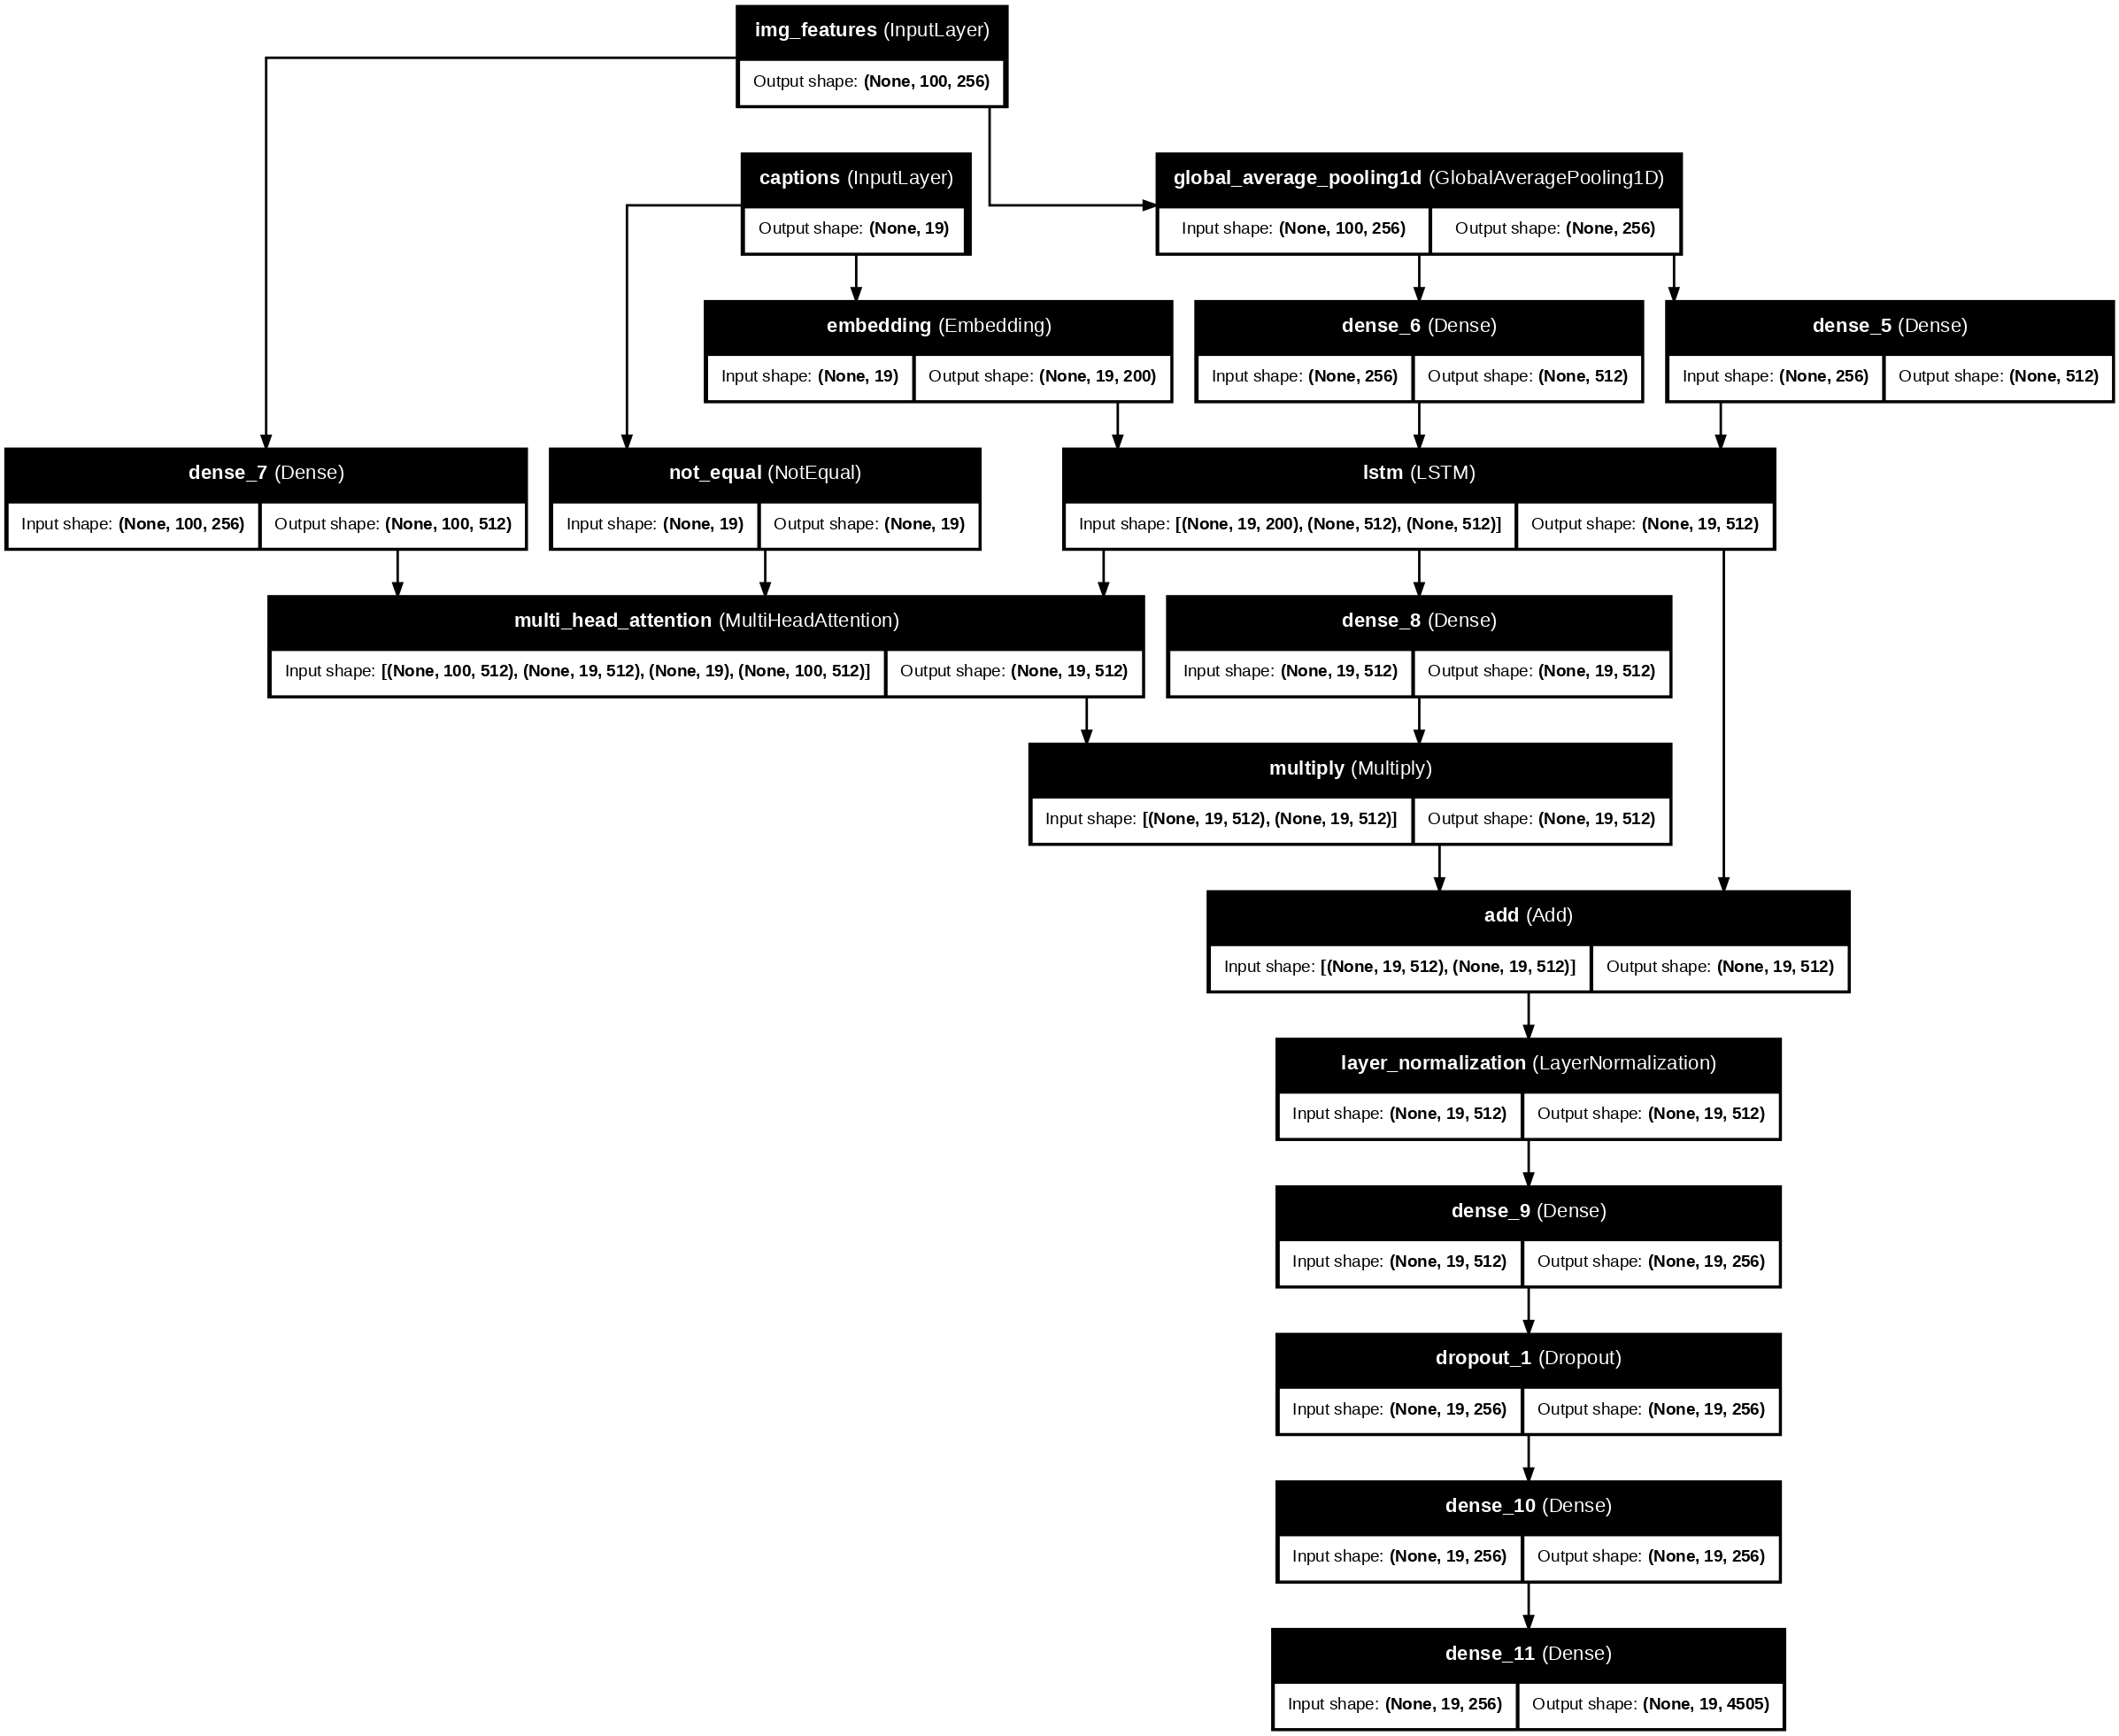

In [79]:
from tensorflow.keras.utils import plot_model

plot_model(decoder_model, 
           to_file="decoder_model.png", 
           show_shapes=True,     
           show_layer_names=True, 
           expand_nested=True,   
           dpi=100)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,                 # stop earlier to prevent overfit
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,               # shrink LR faster if stuck
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_decoder_additive.h5",
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,  # full model (weights+arch)
        verbose=1
    )
]


history = decoder_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=55,             
    callbacks=callbacks,
    verbose=1
)


----------------------------------------------------------------------------------------------------------------------------------------------------

# **SAVING OUR MODEL**

In [73]:
# Saving our model 

decoder_model.save("decoder_model_additive.keras")

print("Model saved as 'decoder_model_additive.keras'")

# (why not .h5 but keras , beacuse in my masked_loss i have a layer called NOT_EQUAL which is not preedefined in kearas, so it shows error always )

Model saved as 'decoder_model_additive.keras'


In [75]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import custom_object_scope


with custom_object_scope({'masked_loss': masked_loss}):
    decoder_model = load_model("/kaggle/input/my-model/decoder_model_new.keras")

print("Model Loaded Succesfully")

Model Loaded Succesfully


------------------------------------------------------------------------------------------------------------------------------------------------

# **GENERATING SOME CAPTIONS ON TEST IMAGES**

In [ ]:
# Helper: Convert token ids to caption string

def tokens_to_caption(tokens):
    
    words = []
    
    for t in tokens:
        if t == 0:  # PAD
            continue
        
        word = index_to_word.get(t, '')
        
        if word == '<end>':
            break
        words.append(word)
    return ' '.join(words)





def beam_search_decoder(img_feat, beam_width=3, max_len=20):
    
    start = word_to_index['<start>']
    end = word_to_index['<end>']
    
    sequences = [[ [start], 0.0 ]]
    
    for _ in range(max_len):
        
        all_candidates = []
        
        for seq, score in sequences:
            if seq[-1] == end:
                all_candidates.append([seq, score])
                continue
            
            cap_input = pad_sequences([seq], maxlen=max_len-1, padding='post')  # shape (1, T)
            
            img_input = np.expand_dims(img_feat, axis=0)                        # [1, 100, 256]
            
            preds = decoder_model.predict([img_input, cap_input], verbose=0)    # [1, T, vocab_size]
            preds = preds[0, len(seq)-1]
            
            top_indices = np.argsort(preds)[-beam_width:][::-1]
            
            for i in top_indices:
                candidate = [seq + [i], score - np.log(preds[i]+1e-9)]
                all_candidates.append(candidate)
        
        sequences = sorted(all_candidates, key=lambda tup: tup[1])[:beam_width]
    
    return sequences[0][0]




def show_image_and_captions(idx, beam_width=5):
    
    img_path = paths_val[idx]
    img_feat = all_features[img_to_idx[img_path]]
    
    
    # Show image
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
   
    # Original captions
    orig = df[df['image_path'] == img_path]['caption'].tolist()
    print("Original Captions:")
    for i, c in enumerate(orig):
        print(f"{i+1}. {c}")
    
    
    # Generated caption
    gen_tokens = beam_search_decoder(img_feat, beam_width=beam_width)
    gen_caption = tokens_to_caption(gen_tokens)
    print("\nGenerated Caption:")
    print(gen_caption)
    print("\n" + "="*80 + "\n")




num_samples = 5
sample_indices = random.sample(range(len(paths_test)), num_samples)

for idx in sample_indices:
    show_image_and_captions(idx, beam_width=5)

-------------------------------------------------------------------------------------

# **EVALUATING BLEU**

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction


# Settings
subset_size = 500          # number of test samples to evaluate
beam_width = 5             # beam search width
smooth_fn = SmoothingFunction().method1  # smoothing for BLEU


# Helper: Convert token list to words
def tokens_to_words(tokens):
    return [index_to_word[t] for t in tokens if t != word_to_index["<pad>"]]


# Pick random test subset
test_indices = list(range(len(paths_test)))
sample_indices = random.sample(test_indices, subset_size)


# Initialize BLEU lists
bleu1_list, bleu2_list, bleu3_list, bleu4_list = [], [], [], []


# Compute BLEU scores
for idx in sample_indices:
    
    # 1. Get image feature
    img_feat = all_features[img_to_idx[paths_test[idx]]]

    
    # 2. Get reference captions for this image
    references = []
    img_captions = df[df['image_path'] == paths_test[idx]]['caption'].tolist()
    for cap in img_captions:
        tokens = encode_caption(cap, max_len=MAX_LEN)
        references.append(tokens_to_words(tokens))

    
    # 3. Generate caption using beam search
    gen_tokens = beam_search_decoder(img_feat, beam_width=beam_width, max_len=MAX_LEN)
    gen_caption = tokens_to_words(gen_tokens)

    
    bleu1_list.append(sentence_bleu(references, gen_caption, weights=(1,0,0,0), smoothing_function=smooth_fn))
    bleu2_list.append(sentence_bleu(references, gen_caption, weights=(0.5,0.5,0,0), smoothing_function=smooth_fn))
    bleu3_list.append(sentence_bleu(references, gen_caption, weights=(0.33,0.33,0.33,0), smoothing_function=smooth_fn))
    bleu4_list.append(sentence_bleu(references, gen_caption, weights=(0.25,0.25,0.25,0.25), smoothing_function=smooth_fn))



print("Average BLEU scores on 500 test images:")
print(f"BLEU-1: {np.mean(bleu1_list):.4f}")
print(f"BLEU-2: {np.mean(bleu2_list):.4f}")
print(f"BLEU-3: {np.mean(bleu3_list):.4f}")
print(f"BLEU-4: {np.mean(bleu4_list):.4f}")


----------------------------------------------------------------------------------------

 # **EVALUATING METEOR**

In [77]:
from nltk.translate.meteor_score import meteor_score


def evaluate_meteor(paths, beam_width=5):
    scores = []
    
    for img_path in tqdm(paths, desc="Calculating METEOR"):
        # 1. Get image features
        img_feat = all_features[img_to_idx[img_path]]

        # 2. Generate caption
        gen_tokens = beam_search_decoder(img_feat, beam_width=beam_width)
        gen_caption = tokens_to_caption(gen_tokens)

        # 3. Get reference captions
        references = df[df['image_path'] == img_path]['caption'].tolist()

        # 4. Calculate METEOR (NLTK expects tokens, so split())
        score = meteor_score([ref.split() for ref in references], gen_caption.split())
        scores.append(score)

    return np.mean(scores)


# Run on test set

meteor_avg = evaluate_meteor(paths_test[:500], beam_width=5)   
print(f"Average METEOR score: {meteor_avg:.4f}")


Calculating METEOR: 100%|██████████| 500/500 [37:30<00:00,  4.50s/it]

Average METEOR score: 0.3987
